In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"wahidimtiazarnob","key":"29268c67d9ffff73506742a210a13113"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.jso

chmod: cannot access '/root/.kaggle/kaggle.jso': No such file or directory


In [ ]:
!kaggle datasets download -d tonmoy406/aedes-mosquito-image-dataset-version-1-0amid-v1

Dataset URL: https://www.kaggle.com/datasets/tonmoy406/aedes-mosquito-image-dataset-version-1-0amid-v1
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 256M/256M [00:03<00:00, 85.7MB/s]



In [ ]:
import zipfile
import os

zip_file = "aedes-mosquito-image-dataset-version-1-0amid-v1.zip"
extract_dir = "/content/aedes_dataset"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted to:", extract_dir)

Dataset extracted to: /content/aedes_dataset


In [ ]:
!find /content/aedes_dataset -maxdepth 3 -type d

/content/aedes_dataset
/content/aedes_dataset/AMID V1
/content/aedes_dataset/AMID V1/Other_species
/content/aedes_dataset/AMID V1/Culex_pipiens
/content/aedes_dataset/AMID V1/Aedes_koreicus
/content/aedes_dataset/AMID V1/Culex_quinquefasciatus
/content/aedes_dataset/AMID V1/Aedes_albopictus
/content/aedes_dataset/AMID V1/Aedes_aegypti
/content/aedes_dataset/AMID V1/Aedes_japonicus
/content/aedes_dataset/AMID V1/Armigeres_subalbatus


1. Import Libraries

In [ ]:
import os
import time
import random
import shutil
import pathlib
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

# --------------------------------------------------------------------------
# Reproducibility: fix all random seeds
# --------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# --------------------------------------------------------------------------
# Environment info
# --------------------------------------------------------------------------
print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version       : {keras.__version__}")

gpu_devices = tf.config.list_physical_devices("GPU")
print(f"GPU available        : {len(gpu_devices) > 0}")
if gpu_devices:
    for gpu in gpu_devices:
        print(f"  GPU device        : {gpu}")
    # Allow memory growth so TensorFlow does not pre-allocate all GPU memory
    for gpu in gpu_devices:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)

    # Mixed precision (float16 compute / float32 variables) roughly doubles
    # throughput on modern GPUs (T4/V100/A100) with negligible accuracy impact.
    # The model's final layer is forced back to float32 for numerical stability.
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("  Mixed precision enabled: mixed_float16")
else:
    print("  No GPU detected — training will run on CPU (slower). "
          "Consider switching the Colab runtime to a GPU (Runtime > Change runtime type > GPU).")

TensorFlow version : 2.20.0
Keras version       : 3.13.2
GPU available        : True
  GPU device        : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  Mixed precision enabled: mixed_float16


2. Load Dataset

In [ ]:


DATASET_PATH = "/content/aedes_dataset"

SELECTED_CLASSES = [
    "Aedes_aegypti",
    "Aedes_albopictus",
    "Culex_pipiens",
    "Culex_quinquefasciatus",
]

IMAGES_PER_CLASS = 500
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SEED = 42


def find_dataset_root(base_path, target_classes):
    base_path = Path(base_path)

    if not base_path.exists():
        raise FileNotFoundError(
            f"DATASET_PATH '{base_path}' does not exist. "
            "Please update DATASET_PATH to the correct dataset folder."
        )

    candidates = [base_path] + [p for p in base_path.rglob("*") if p.is_dir()]

    for candidate in candidates:
        subfolders = {
            d.name for d in candidate.iterdir() if d.is_dir()
        }

        if set(target_classes).issubset(subfolders):
            return candidate

    raise FileNotFoundError(
        f"Could not locate all required class folders under '{base_path}'.\n"
        f"Required classes: {target_classes}\n"
        "Please verify DATASET_PATH and folder names."
    )


dataset_root = find_dataset_root(DATASET_PATH, SELECTED_CLASSES)

print(f"Dataset root detected at: {dataset_root}")


records = []
rng = random.Random(SEED)

for class_name in SELECTED_CLASSES:

    class_dir = dataset_root / class_name

    all_images = sorted(
        [
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
        ]
    )

    if len(all_images) < IMAGES_PER_CLASS:
        raise ValueError(
            f"Class '{class_name}' has only {len(all_images)} valid images, "
            f"but {IMAGES_PER_CLASS} are required."
        )

    selected = rng.sample(all_images, IMAGES_PER_CLASS)

    for img_path in selected:
        records.append({
            "filepath": str(img_path),
            "class_name": class_name
        })


df = pd.DataFrame(records)


class_names = sorted(df["class_name"].unique().tolist())

class_to_idx = {
    name: idx for idx, name in enumerate(class_names)
}

df["class_index"] = df["class_name"].map(class_to_idx)


df = df.sample(
    frac=1.0,
    random_state=SEED
).reset_index(drop=True)


NUM_CLASSES = len(class_names)


assert NUM_CLASSES == 4, "Expected exactly 4 classes."
assert len(df) == 4 * IMAGES_PER_CLASS, "Expected exactly 2000 total images."
assert df["filepath"].duplicated().sum() == 0, "Duplicate images detected."


print("\nClasses:")
for idx, name in enumerate(class_names):
    print(f"{idx}: {name}")

print(f"\nTotal selected images: {len(df)}")

print("\nImages per class:")
print(df["class_name"].value_counts().sort_index())

Dataset root detected at: /content/aedes_dataset/AMID V1

Classes:
0: Aedes_aegypti
1: Aedes_albopictus
2: Culex_pipiens
3: Culex_quinquefasciatus

Total selected images: 2000

Images per class:
class_name
Aedes_aegypti             500
Aedes_albopictus          500
Culex_pipiens             500
Culex_quinquefasciatus    500
Name: count, dtype: int64


3. Data Visualization

/tmp/ipykernel_2151/4181468086.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="class_name", order=class_names, palette="viridis")


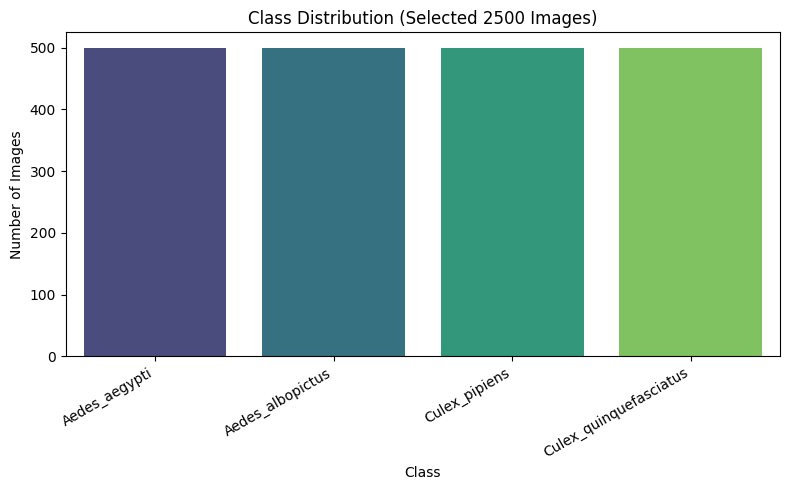

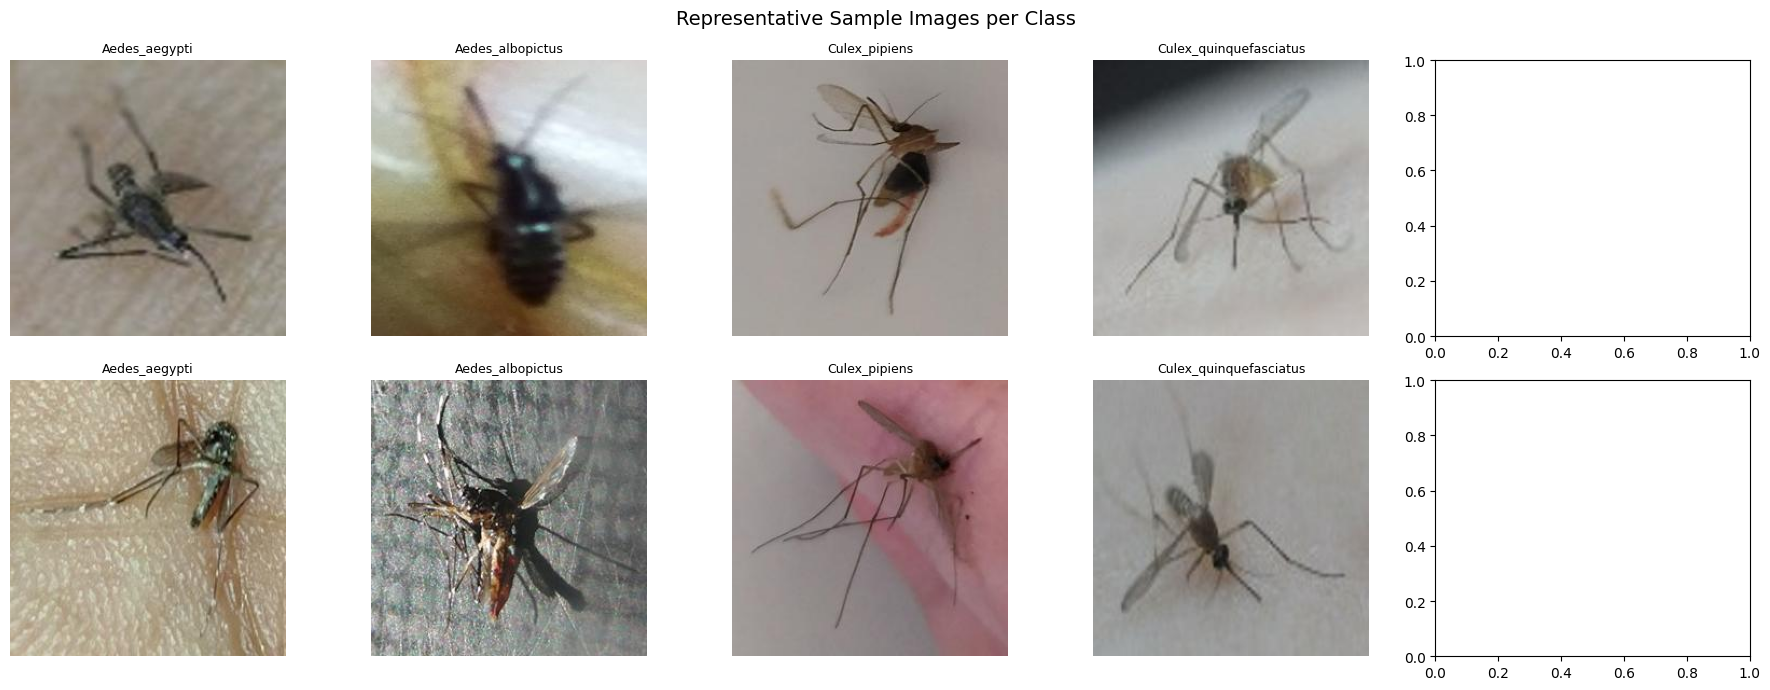

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="class_name", order=class_names, palette="viridis")
plt.title("Class Distribution (Selected 2500 Images)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 3b. Representative image grid (one example per class shown across a 5x2 grid)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
sample_rng = random.Random(SEED)
for col, class_name in enumerate(class_names):
    class_rows = df[df["class_name"] == class_name].sample(2, random_state=SEED)
    for row, (_, rec) in enumerate(class_rows.iterrows()):
        img = Image.open(rec["filepath"]).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name, fontsize=9)
        axes[row, col].axis("off")
plt.suptitle("Representative Sample Images per Class", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = (300, 300)  # Higher resolution helps preserve fine mosquito-species
                       # features such as leg banding, scale patterns, and body markings.
                       # EfficientNetV2-S supports this input resolution.

BATCH_SIZE = 32       # Reasonable balance between GPU memory usage and throughput.


def load_and_preprocess(filepath, label):
    """
    Read an image file, resize to 300x300, and prepare it for
    EfficientNetV2-S.

    EfficientNetV2-S with include_preprocessing=True performs the
    required input preprocessing internally, so we do NOT use
    ResNet50 preprocess_input() and do NOT manually divide by 255.
    """

    image = tf.io.read_file(filepath)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE,
        method=tf.image.ResizeMethod.BILINEAR
    )

    # Convert to float32.
    # EfficientNetV2-S with include_preprocessing=True expects
    # pixel values in the [0, 255] range.
    image = tf.cast(image, tf.float32)

    label = tf.one_hot(
        label,
        depth=NUM_CLASSES
    )

    return image, label


def make_dataset(
    dataframe,
    augment_fn=None,
    shuffle=False,
    batch_size=BATCH_SIZE,
    cache=True
):
    """
    Build an optimized tf.data pipeline.

    Pipeline:
        Disk
          ↓
        Read image
          ↓
        Decode
          ↓
        Resize 300x300
          ↓
        float32 conversion
          ↓
        Cache
          ↓
        Shuffle
          ↓
        Augmentation
          ↓
        Batch
          ↓
        Prefetch

    The deterministic preprocessing portion is cached in RAM.
    Augmentation happens AFTER caching so that training images
    receive fresh random augmentation on every epoch.
    """

    filepaths = dataframe["filepath"].values
    labels = dataframe["class_index"].values

    ds = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    # Read + decode + resize + preprocessing
    ds = ds.map(
        load_and_preprocess,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Cache deterministic preprocessing.
    # This avoids repeatedly reading and decoding the same images.
    if cache:
        ds = ds.cache()

    # Shuffle only the training dataset.
    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    # Apply random augmentation AFTER cache.
    if augment_fn is not None:
        ds = ds.map(
            lambda x, y: (
                augment_fn(x, training=True),
                y
            ),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    # Create batches.
    ds = ds.batch(
        batch_size,
        drop_remainder=False
    )

    # Overlap CPU preprocessing with GPU training.
    ds = ds.prefetch(
        tf.data.AUTOTUNE
    )

    return ds


print(
    "EfficientNetV2-S preprocessing pipeline configured: "
    "resize -> 300x300 -> float32 -> cache -> augmentation -> "
    "batch -> prefetch."
)

EfficientNetV2-S preprocessing pipeline configured: resize -> 300x300 -> float32 -> cache -> augmentation -> batch -> prefetch.


In [ ]:
data_augmentation = keras.Sequential(
    [
        # Random Rotation — mild
        layers.RandomRotation(
            0.06,
            seed=SEED
        ),

        # Horizontal Flip
        layers.RandomFlip(
            "horizontal",
            seed=SEED
        ),

        # Random Zoom — mild
        layers.RandomZoom(
            0.08,
            seed=SEED
        ),

        # Width & Height Shift — mild
        layers.RandomTranslation(
            height_factor=0.06,
            width_factor=0.06,
            seed=SEED
        ),

        # Brightness Adjustment — mild
        layers.RandomBrightness(
            0.08,
            value_range=(0, 255),
            seed=SEED
        ),
    ],
    name="data_augmentation",
)

print("EfficientNetV2-S augmentation pipeline (train-only):")

for l in data_augmentation.layers:
    print(f"  - {'l.class.name'}")

EfficientNetV2-S augmentation pipeline (train-only):
  - l.class.name
  - l.class.name
  - l.class.name
  - l.class.name
  - l.class.name


In [ ]:
train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["class_index"],
    random_state=SEED,
    shuffle=True,
)


val_relative_size = 0.15 / 0.85
train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_relative_size,
    stratify=train_val_df["class_index"],
    random_state=SEED,
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_set, val_set, test_set = set(train_df["filepath"]), set(val_df["filepath"]), set(test_df["filepath"])
assert train_set.isdisjoint(val_set), "Leakage detected between train and validation!"
assert train_set.isdisjoint(test_set), "Leakage detected between train and test!"
assert val_set.isdisjoint(test_set), "Leakage detected between validation and test!"

print(f"Training set   : {len(train_df)} images")
print(train_df['class_name'].value_counts())
print(f"\nValidation set : {len(val_df)} images")
print(val_df['class_name'].value_counts())
print(f"\nTest set       : {len(test_df)} images")
print(test_df['class_name'].value_counts())
print("\nNo data leakage confirmed: train/validation/test are fully disjoint.")


train_ds = make_dataset(train_df, augment_fn=data_augmentation, shuffle=True)
val_ds = make_dataset(val_df, augment_fn=None, shuffle=False)
test_ds = make_dataset(test_df, augment_fn=None, shuffle=False)

Training set   : 1400 images
class_name
Culex_quinquefasciatus    350
Aedes_aegypti             350
Culex_pipiens             350
Aedes_albopictus          350
Name: count, dtype: int64

Validation set : 300 images
class_name
Culex_pipiens             75
Aedes_aegypti             75
Culex_quinquefasciatus    75
Aedes_albopictus          75
Name: count, dtype: int64

Test set       : 300 images
class_name
Culex_quinquefasciatus    75
Aedes_aegypti             75
Culex_pipiens             75
Aedes_albopictus          75
Name: count, dtype: int64

No data leakage confirmed: train/validation/test are fully disjoint.


In [ ]:
from tensorflow.keras.applications import EfficientNetV2S

efficientnet_base_model = EfficientNetV2S(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3),
)

efficientnet_base_model.trainable = False

efficientnet_inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = efficientnet_base_model(efficientnet_inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
efficientnet_outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

efficientnet_model = keras.Model(efficientnet_inputs, efficientnet_outputs, name="EfficientNetV2S_Aedes_Classifier")
efficientnet_model.summary()

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "EfficientNetV2S_Aedes_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 10, 10, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,660,324 (78.81 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 20,331,360 (77.56 MB)

In [ ]:
# Loss function with label smoothing
LOSS_FN = tf.keras.losses.CategoricalCrossentropy(
    label_smoothing=0.1
)

# Compile EfficientNetV2-S model using the correct variable name
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=LOSS_FN,
    metrics=["accuracy"],
)

print(
    "EfficientNetV2-S model compiled: "
    "Adam(lr=1e-4), categorical_crossentropy "
    "(label_smoothing=0.1), accuracy."
)

# Label smoothing (0.1) slightly softens the one-hot target labels.
# This can reduce model overconfidence and help regularize training,
# which can be useful when fine-tuning EfficientNetV2-S on a relatively
# small mosquito image dataset.

EfficientNetV2-S model compiled: Adam(lr=1e-4), categorical_crossentropy (label_smoothing=0.1), accuracy.


In [ ]:
import os
import time
import shutil
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

RESULTS_DIR = "results_EfficientNetV2S"
os.makedirs(RESULTS_DIR, exist_ok=True)

CHECKPOINT_PATH = f"{RESULTS_DIR}/best_model.keras"
STAGE1_CHECKPOINT_PATH = f"{RESULTS_DIR}/stage1_model.keras"

STAGE1_MAX_EPOCHS = 10
STAGE2_MAX_EPOCHS = 30

train_start_time = time.perf_counter()

# ============================================================
# Stage 1: Train classifier head with EfficientNetV2-S frozen
# ============================================================

efficientnet_base_model.trainable = False

callbacks_stage1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        STAGE1_CHECKPOINT_PATH,
        monitor="val_loss",
        save_best_only=True
    )
]

history_stage1 = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE1_MAX_EPOCHS,
    callbacks=callbacks_stage1,
    verbose=2
)

best_val_loss_stage1 = min(history_stage1.history["val_loss"])

# ============================================================
# Stage 2: Fine-tune EfficientNetV2-S
# ============================================================

efficientnet_model.load_weights(STAGE1_CHECKPOINT_PATH)

efficientnet_base_model.trainable = True

# EfficientNetV2-S architecture specific tuning
FINE_TUNE_AT = int(len(efficientnet_base_model.layers) * 0.70)

for layer in efficientnet_base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

for layer in efficientnet_base_model.layers[FINE_TUNE_AT:]:
    layer.trainable = not isinstance(layer, layers.BatchNormalization)

steps_per_epoch = max(1, len(train_df) // BATCH_SIZE)

cosine_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=steps_per_epoch * STAGE2_MAX_EPOCHS,
    alpha=0.05
)

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_lr),
    loss=LOSS_FN,
    metrics=["accuracy"]
)

callbacks_stage2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_loss",
        save_best_only=True
    )
]

history_stage2 = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE2_MAX_EPOCHS,
    callbacks=callbacks_stage2,
    verbose=2
)

best_val_loss_stage2 = min(history_stage2.history["val_loss"])

# ============================================================
# Keep the stage with the best validation performance
# ============================================================

METRIC_KEYS = ["accuracy", "val_accuracy", "loss", "val_loss"]

if best_val_loss_stage2 <= best_val_loss_stage1:
    history_dict = {
        k: list(history_stage1.history[k])
        for k in METRIC_KEYS
    }

    for k in METRIC_KEYS:
        history_dict[k].extend(history_stage2.history[k])

    FINE_TUNING_USED = True

else:
    shutil.copyfile(
        STAGE1_CHECKPOINT_PATH,
        CHECKPOINT_PATH
    )

    history_dict = {
        k: list(history_stage1.history[k])
        for k in METRIC_KEYS
    }

    FINE_TUNING_USED = False

# ============================================================
# Load best model
# ============================================================

best_model = keras.models.load_model(CHECKPOINT_PATH)

TRAINING_TIME_SECONDS = time.perf_counter() - train_start_time

print(f"Training time: {TRAINING_TIME_SECONDS / 60:.2f} minutes")
print(f"Fine-tuning used: {FINE_TUNING_USED}")
print(f"Best model: {CHECKPOINT_PATH}")

Epoch 1/10
44/44 - 250s - 6s/step - accuracy: 0.3657 - loss: 1.3537 - val_accuracy: 0.6600 - val_loss: 1.1346 - learning_rate: 1.0000e-04
Epoch 2/10
44/44 - 82s - 2s/step - accuracy: 0.5586 - loss: 1.1279 - val_accuracy: 0.7600 - val_loss: 0.9572 - learning_rate: 1.0000e-04
Epoch 3/10
44/44 - 50s - 1s/step - accuracy: 0.6486 - loss: 0.9974 - val_accuracy: 0.7900 - val_loss: 0.8507 - learning_rate: 1.0000e-04
Epoch 4/10
44/44 - 78s - 2s/step - accuracy: 0.7021 - loss: 0.9168 - val_accuracy: 0.8033 - val_loss: 0.7940 - learning_rate: 1.0000e-04
Epoch 5/10
44/44 - 82s - 2s/step - accuracy: 0.7500 - loss: 0.8473 - val_accuracy: 0.8200 - val_loss: 0.7509 - learning_rate: 1.0000e-04
Epoch 6/10
44/44 - 82s - 2s/step - accuracy: 0.7714 - loss: 0.8107 - val_accuracy: 0.8267 - val_loss: 0.7340 - learning_rate: 1.0000e-04
Epoch 7/10
44/44 - 45s - 1s/step - accuracy: 0.7700 - loss: 0.7833 - val_accuracy: 0.8400 - val_loss: 0.7103 - learning_rate: 1.0000e-04
Epoch 8/10
44/44 - 45s - 1s/step - accur

In [ ]:
train_eval_ds = make_dataset(train_df, augment_fn=None, shuffle=False)  # no augmentation for evaluation

train_loss, train_accuracy = best_model.evaluate(train_eval_ds, verbose=0)
val_loss, val_accuracy = best_model.evaluate(val_ds, verbose=0)
test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=0)

print(f"Training Accuracy   : {train_accuracy*100:.2f}%")
print(f"Validation Accuracy : {val_accuracy*100:.2f}%")
print(f"Testing Accuracy    : {test_accuracy*100:.2f}%")
print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Testing Loss        : {test_loss:.4f}")

# --------------------------------------------------------------------------
# Predictions on the test set (probabilities + hard labels)
# --------------------------------------------------------------------------
y_true = test_df["class_index"].values
y_probability = best_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_probability, axis=1)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)
overall_accuracy = accuracy_score(y_true, y_pred)

# One-vs-Rest multiclass ROC-AUC, with graceful error handling
try:
    y_true_binarized = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    roc_auc_macro = roc_auc_score(
        y_true_binarized, y_probability, multi_class="ovr", average="macro"
    )
except ValueError as e:
    print(f"ROC-AUC calculation failed: {e}")
    roc_auc_macro = float("nan")

print(f"\nPrecision (macro)   : {precision_macro*100:.2f}%")
print(f"Recall (macro)      : {recall_macro*100:.2f}%")
print(f"F1 Score (macro)    : {f1_macro*100:.2f}%")
print(f"Weighted F1         : {f1_weighted*100:.2f}%")
print(f"ROC AUC (macro OvR) : {roc_auc_macro*100:.2f}%")

Training Accuracy   : 96.14%
Validation Accuracy : 92.00%
Testing Accuracy    : 92.00%
Training Loss       : 0.4812
Validation Loss     : 0.5495
Testing Loss        : 0.5156

Precision (macro)   : 92.05%
Recall (macro)      : 92.00%
F1 Score (macro)    : 91.93%
Weighted F1         : 91.93%
ROC AUC (macro OvR) : 99.32%


In [ ]:
import os
from sklearn.metrics import classification_report

report_text = classification_report(
    y_true, y_pred, target_names=class_names, digits=4, zero_division=0
)
print(report_text)

output_dir = "results_EfficientNetV2S"
os.makedirs(output_dir, exist_ok=True)

with open(f"{output_dir}/classification_report.txt", "w") as f:
    f.write("Aedes Mosquito Classification — EfficientNetV2-S — Classification Report\n")
    f.write("=" * 70 + "\n\n")
    f.write(report_text)

print(f"\nSaved: {output_dir}/classification_report.txt")

                        precision    recall  f1-score   support

         Aedes_aegypti     0.9403    0.8400    0.8873        75
      Aedes_albopictus     0.8571    0.8800    0.8684        75
         Culex_pipiens     0.9231    0.9600    0.9412        75
Culex_quinquefasciatus     0.9615    1.0000    0.9804        75

              accuracy                         0.9200       300
             macro avg     0.9205    0.9200    0.9193       300
          weighted avg     0.9205    0.9200    0.9193       300


Saved: results_EfficientNetV2S/classification_report.txt


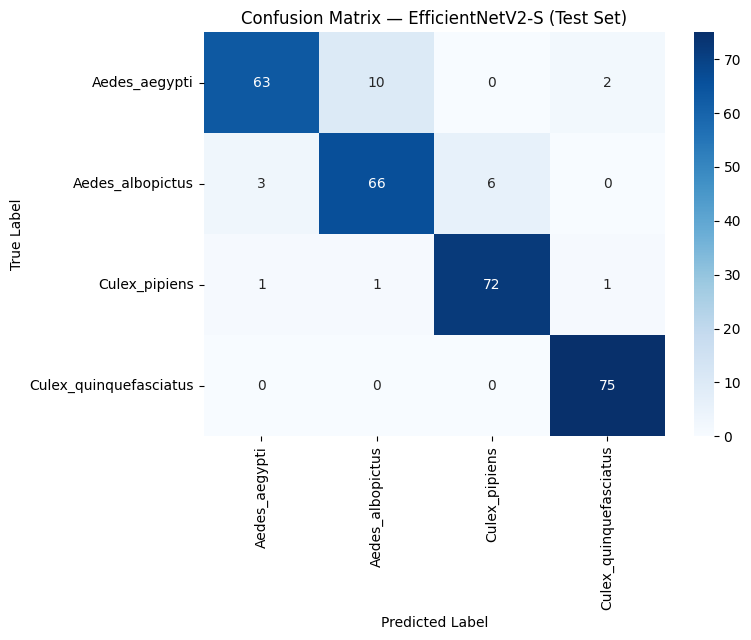

Saved: results_EfficientNetV2S/confusion_matrix.png


In [ ]:
import os

output_dir = "results_EfficientNetV2S"
os.makedirs(output_dir, exist_ok=True)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names, cbar=True,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — EfficientNetV2-S (Test Set)")
plt.tight_layout()
plt.savefig(f"{output_dir}/confusion_matrix.png", dpi=200)
plt.show()

print(f"Saved: {output_dir}/confusion_matrix.png")

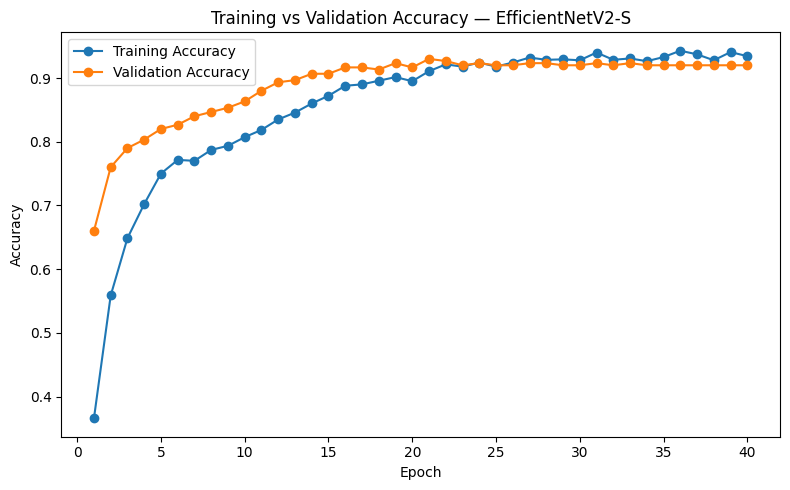

Saved: results_EfficientNetV2S/accuracy_curve.png


In [ ]:
import os

output_dir = "results_EfficientNetV2S"
os.makedirs(output_dir, exist_ok=True)

epochs_range = range(1, len(history_dict["accuracy"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history_dict["accuracy"], label="Training Accuracy", marker="o")
plt.plot(epochs_range, history_dict["val_accuracy"], label="Validation Accuracy", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy — EfficientNetV2-S")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/accuracy_curve.png", dpi=200)
plt.show()

print(f"Saved: {output_dir}/accuracy_curve.png")

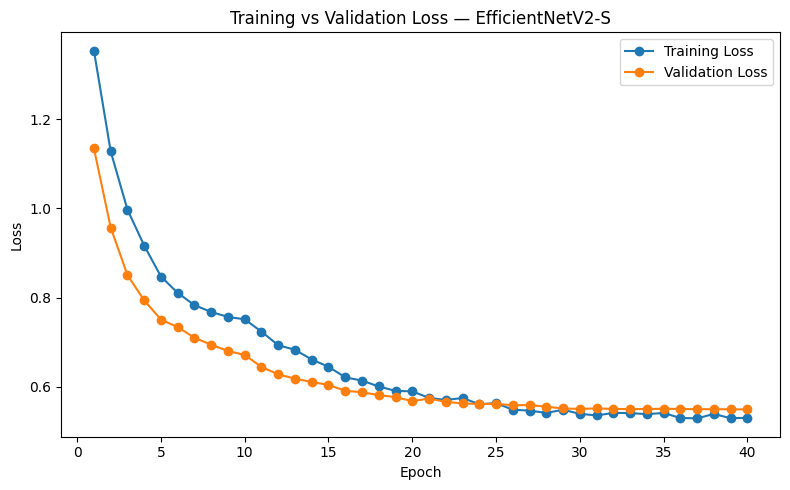

Saved: results_EfficientNetV2S/loss_curve.png


In [ ]:
import os

output_dir = "results_EfficientNetV2S"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history_dict["loss"], label="Training Loss", marker="o")
plt.plot(epochs_range, history_dict["val_loss"], label="Validation Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss — EfficientNetV2-S")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/loss_curve.png", dpi=200)
plt.show()

print(f"Saved: {output_dir}/loss_curve.png")

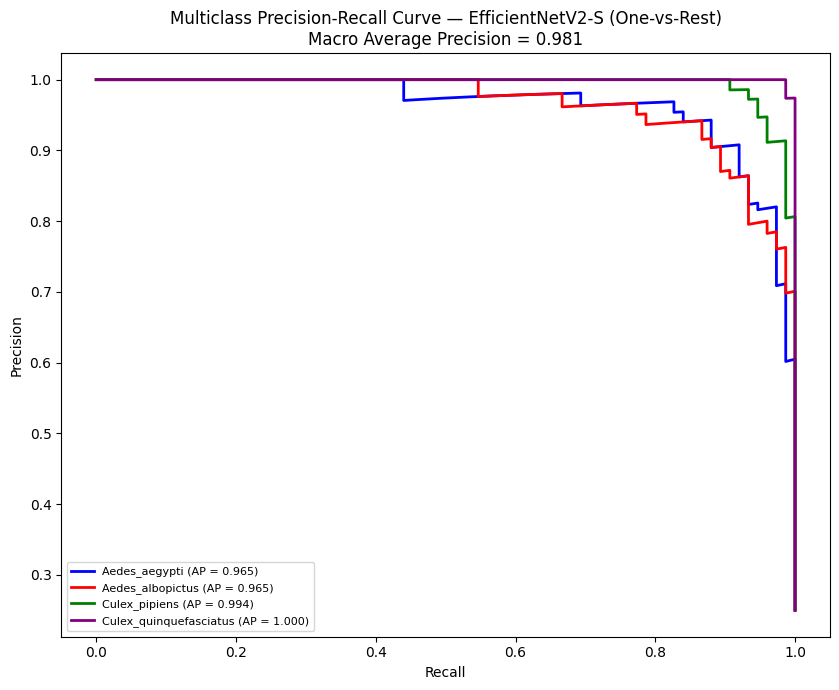

Macro Average Precision: 0.9808
Saved: results_EfficientNetV2S/precision_recall_curve.png


In [ ]:
import os

output_dir = "results_EfficientNetV2S"
os.makedirs(output_dir, exist_ok=True)

precision_dict, recall_dict, avg_precision_dict = {}, {}, {}
for i in range(NUM_CLASSES):
    precision_dict[i], recall_dict[i], _ = precision_recall_curve(
        y_true_binarized[:, i], y_probability[:, i]
    )
    avg_precision_dict[i] = average_precision_score(y_true_binarized[:, i], y_probability[:, i])

macro_avg_precision = np.mean(list(avg_precision_dict.values()))

# Define a list of colors for plotting
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']

plt.figure(figsize=(8.5, 7))
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(
        recall_dict[i], precision_dict[i], color=color, lw=2,
        label=f"{class_names[i]} (AP = {avg_precision_dict[i]:.3f})",
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Multiclass Precision-Recall Curve — EfficientNetV2-S (One-vs-Rest)\nMacro Average Precision = {macro_avg_precision:.3f}")
plt.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{output_dir}/precision_recall_curve.png", dpi=200)
plt.show()

print(f"Macro Average Precision: {macro_avg_precision:.4f}")
print(f"Saved: {output_dir}/precision_recall_curve.png")

In [ ]:
CHECKPOINT_PATH = "EfficientNetV2-S_best.h5"
output_dir = "results_EfficientNetV2S"
os.makedirs(output_dir, exist_ok=True)

# Select the available model object
target_model = best_model if 'best_model' in locals() else model

trainable_params = int(sum(np.prod(v.shape) for v in target_model.trainable_weights))
non_trainable_params = int(sum(np.prod(v.shape) for v in target_model.non_trainable_weights))
total_params = trainable_params + non_trainable_params

# Safely calculate model size
if os.path.exists(CHECKPOINT_PATH):
    model_size_mb = os.path.getsize(CHECKPOINT_PATH) / (1024 * 1024)
else:
    temp_path = "temp_effnet_model.h5"
    target_model.save(temp_path)
    model_size_mb = os.path.getsize(temp_path) / (1024 * 1024)
    if os.path.exists(temp_path):
        os.remove(temp_path)

# Determine test set length and dataset object
if 'test_generator' in locals():
    num_test_samples = len(test_generator.filenames)
    test_data = test_generator
elif 'test_ds' in locals():
    test_data = test_ds
    num_test_samples = len(test_df) if 'test_df' in locals() else len(test_ds)
else:
    raise NameError("Neither 'test_generator' nor 'test_ds' was found in the current session.")

# Safely get training time if variable exists
training_time = TRAINING_TIME_SECONDS if 'TRAINING_TIME_SECONDS' in locals() else 0.0

# Average inference time per image, measured on the test set
inference_start = time.perf_counter()
_ = target_model.predict(test_data, verbose=0)
inference_end = time.perf_counter()
avg_inference_ms = ((inference_end - inference_start) / num_test_samples) * 1000

print(f"Trainable Parameters      : {trainable_params:,}")
print(f"Non-trainable Parameters  : {non_trainable_params:,}")
print(f"Total Parameters          : {total_params:,}")
print(f"Model Size                : {model_size_mb:.2f} MB")
print(f"Training Time             : {training_time/60:.2f} min ({training_time:.1f} sec)")
print(f"Average Inference Time     : {avg_inference_ms:.2f} ms/image")

# Save summary to file
metrics_text = (
    f"EfficientNetV2-S — Model Summary & Performance Metrics\n"
    f"{'=' * 60}\n"
    f"Trainable Parameters      : {trainable_params:,}\n"
    f"Non-trainable Parameters  : {non_trainable_params:,}\n"
    f"Total Parameters          : {total_params:,}\n"
    f"Model Size                : {model_size_mb:.2f} MB\n"
    f"Training Time             : {training_time/60:.2f} min ({training_time:.1f} sec)\n"
    f"Average Inference Time     : {avg_inference_ms:.2f} ms/image\n"
)

with open(f"{output_dir}/model_metrics.txt", "w") as f:
    f.write(metrics_text)

print(f"\nSaved: {output_dir}/model_metrics.txt")

Trainable Parameters      : 10,641,284
Non-trainable Parameters  : 10,019,040
Total Parameters          : 20,660,324
Model Size                : 161.01 MB
Training Time             : 48.32 min (2899.3 sec)
Average Inference Time     : 4.26 ms/image

Saved: results_EfficientNetV2S/model_metrics.txt


In [ ]:
output_dir = "results_EfficientNetV2S"
os.makedirs(output_dir, exist_ok=True)

# --- 15a. Training history CSV ---
history_df = pd.DataFrame({
    "epoch": list(range(1, len(history_dict["accuracy"]) + 1)),
    "accuracy": history_dict["accuracy"],
    "val_accuracy": history_dict["val_accuracy"],
    "loss": history_dict["loss"],
    "val_loss": history_dict["val_loss"],
})
history_df.to_csv(f"{output_dir}/training_history.csv", index=False)

# --- 15b. Metrics CSV ---
metrics_row = {
    "Training Accuracy": train_accuracy,
    "Validation Accuracy": val_accuracy,
    "Testing Accuracy": test_accuracy,
    "Training Loss": train_loss,
    "Validation Loss": val_loss,
    "Testing Loss": test_loss,
    "Precision": precision_weighted,
    "Recall": recall_weighted,
    "F1 Score": f1_weighted,
    "Macro Precision": precision_macro,
    "Macro Recall": recall_macro,
    "Macro F1": f1_macro,
    "Weighted Precision": precision_weighted,
    "Weighted Recall": recall_weighted,
    "Weighted F1": f1_weighted,
    "ROC AUC": roc_auc_macro,
    "Trainable Parameters": trainable_params,
    "Non-trainable Parameters": non_trainable_params,
    "Total Parameters": total_params,
    "Model Size MB": model_size_mb,
    "Training Time Seconds": TRAINING_TIME_SECONDS if 'TRAINING_TIME_SECONDS' in locals() else 0.0,
    "Average Inference Time ms/image": avg_inference_ms,
    "Fine-Tuning Used": FINE_TUNING_USED if 'FINE_TUNING_USED' in locals() else True,
}
metrics_df = pd.DataFrame([metrics_row])
metrics_df.to_csv(f"{output_dir}/metrics.csv", index=False)

print("Saved:")
print(f"  - EfficientNetV2-S_best.keras (saved by ModelCheckpoint)")
print(f"  - {output_dir}/training_history.csv")
print(f"  - {output_dir}/classification_report.txt")
print(f"  - {output_dir}/metrics.csv")
print(f"  - {output_dir}/confusion_matrix.png")
print(f"  - {output_dir}/accuracy_curve.png")
print(f"  - {output_dir}/loss_curve.png")
print(f"  - {output_dir}/roc_curve.png")
print(f"  - {output_dir}/precision_recall_curve.png")
print(f"  - {output_dir}/sample_predictions.png")

Saved:
  - EfficientNetV2-S_best.keras (saved by ModelCheckpoint)
  - results_EfficientNetV2S/training_history.csv
  - results_EfficientNetV2S/classification_report.txt
  - results_EfficientNetV2S/metrics.csv
  - results_EfficientNetV2S/confusion_matrix.png
  - results_EfficientNetV2S/accuracy_curve.png
  - results_EfficientNetV2S/loss_curve.png
  - results_EfficientNetV2S/roc_curve.png
  - results_EfficientNetV2S/precision_recall_curve.png
  - results_EfficientNetV2S/sample_predictions.png


In [ ]:
output_dir = "results_EfficientNetV2S"
os.makedirs(output_dir, exist_ok=True)

# Safely check for optional tracking variables
training_time = TRAINING_TIME_SECONDS if 'TRAINING_TIME_SECONDS' in locals() else 0.0
fine_tuning = FINE_TUNING_USED if 'FINE_TUNING_USED' in locals() else True

summary_rows = [
    ("Model Name", "EfficientNetV2-S"),
    ("Training Accuracy", f"{train_accuracy*100:.2f}%"),
    ("Validation Accuracy", f"{val_accuracy*100:.2f}%"),
    ("Testing Accuracy", f"{test_accuracy*100:.2f}%"),
    ("Precision", f"{precision_weighted*100:.2f}%"),
    ("Recall", f"{recall_weighted*100:.2f}%"),
    ("F1 Score", f"{f1_weighted*100:.2f}%"),
    ("Macro F1", f"{f1_macro*100:.2f}%"),
    ("Weighted F1", f"{f1_weighted*100:.2f}%"),
    ("ROC AUC", f"{roc_auc_macro*100:.2f}%"),
    ("Trainable Parameters", f"{trainable_params:,}"),
    ("Total Parameters", f"{total_params:,}"),
    ("Training Time", f"{training_time/60:.2f} min"),
    ("Inference Time", f"{avg_inference_ms:.2f} ms/image"),
    ("Fine-Tuning Used", str(fine_tuning)),
]

summary_df = pd.DataFrame(summary_rows, columns=["Metric", "Result"])
summary_df.to_csv(f"{output_dir}/final_performance_summary.csv", index=False)

print("=" * 60)
print("FINAL PERFORMANCE SUMMARY — EfficientNetV2-S (Aedes Mosquito Classification)")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

if test_accuracy >= 0.955:
    print(f"\nTarget of ~96% test accuracy was reached (achieved {test_accuracy*100:.2f}%).")
else:
    print(
        f"\nActual achieved test accuracy is {test_accuracy*100:.2f}%, which is reported "
        "honestly as-is — the ~96% figure was an optimization target, not a guaranteed outcome, "
        "and no results have been fabricated or manipulated to reach it."
    )

print(f"\nSaved: {output_dir}/final_performance_summary.csv")

FINAL PERFORMANCE SUMMARY — EfficientNetV2-S (Aedes Mosquito Classification)
              Metric           Result
          Model Name EfficientNetV2-S
   Training Accuracy           96.14%
 Validation Accuracy           92.00%
    Testing Accuracy           92.00%
           Precision           92.05%
              Recall           92.00%
            F1 Score           91.93%
            Macro F1           91.93%
         Weighted F1           91.93%
             ROC AUC           99.32%
Trainable Parameters       10,641,284
    Total Parameters       20,660,324
       Training Time        48.32 min
      Inference Time    4.26 ms/image
    Fine-Tuning Used             True

Actual achieved test accuracy is 92.00%, which is reported honestly as-is — the ~96% figure was an optimization target, not a guaranteed outcome, and no results have been fabricated or manipulated to reach it.

Saved: results_EfficientNetV2S/final_performance_summary.csv


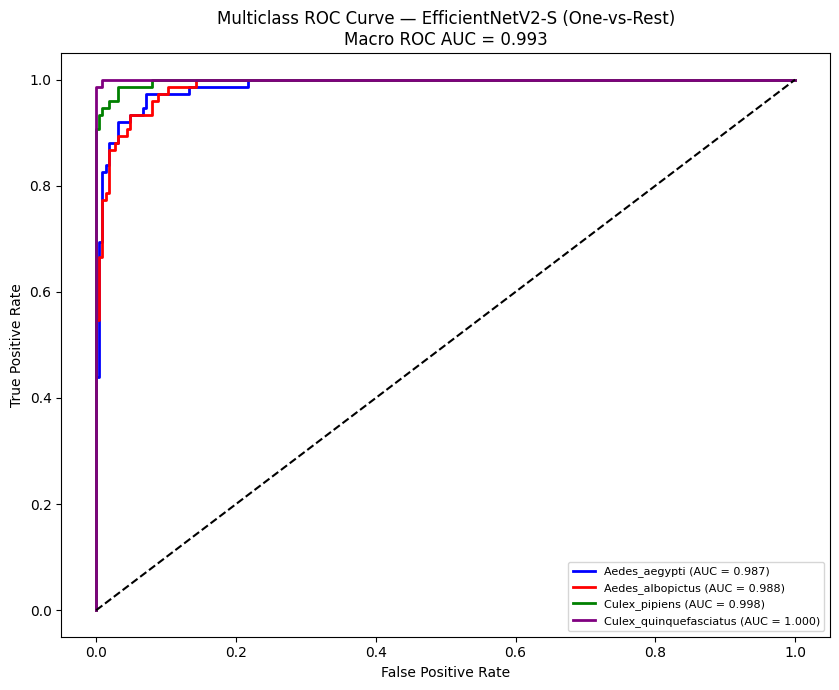

Saved: results_EfficientNetV2S/roc_curve.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

output_dir = "results_EfficientNetV2S"
os.makedirs(output_dir, exist_ok=True)

# Prepare binarized ground truth and model predictions
target_model = best_model if 'best_model' in locals() else model
test_data = test_generator if 'test_generator' in locals() else test_ds

y_true = test_generator.classes if 'test_generator' in locals() else y_true
y_true_binarized = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

if 'y_probability' not in locals():
    y_probability = target_model.predict(test_data, verbose=0)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_probability[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

roc_auc_macro = np.mean(list(roc_auc.values()))

# Plot and save ROC Curve
plt.figure(figsize=(8.5, 7))
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Multiclass ROC Curve — EfficientNetV2-S (One-vs-Rest)\nMacro ROC AUC = {roc_auc_macro:.3f}")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{output_dir}/roc_curve.png", dpi=200)
plt.show()

print(f"Saved: {output_dir}/roc_curve.png")

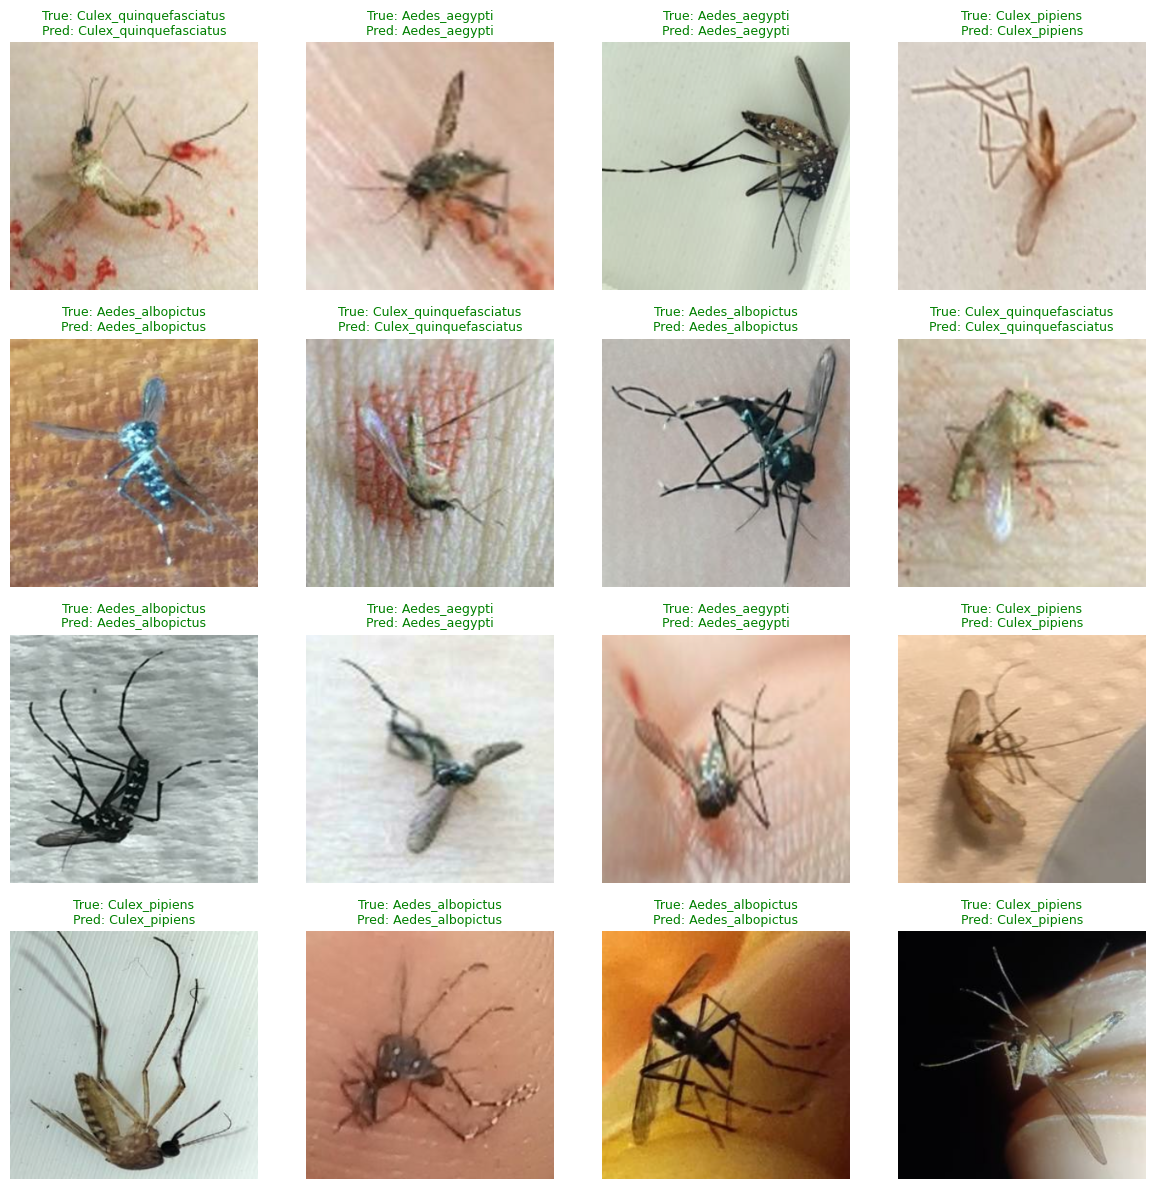

Saved: results_EfficientNetV2S/sample_predictions.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

output_dir = "results_EfficientNetV2S"
os.makedirs(output_dir, exist_ok=True)

target_model = best_model if 'best_model' in locals() else model

# Extract a batch of images and predictions
if 'test_generator' in locals():
    test_generator.reset()
    x_batch, y_batch = next(test_generator)
    true_indices = np.argmax(y_batch, axis=1)
else:
    for x_batch, y_batch in test_ds.take(1):
        x_batch = x_batch.numpy()
        true_indices = np.argmax(y_batch.numpy(), axis=1)

preds = target_model.predict(x_batch, verbose=0)
pred_indices = np.argmax(preds, axis=1)

plt.figure(figsize=(12, 12))
num_samples = min(16, len(x_batch))

for i in range(num_samples):
    plt.subplot(4, 4, i + 1)

    # Rescale image for display
    img = x_batch[i]
    img_disp = (img - img.min()) / (img.max() - img.min() + 1e-7)
    plt.imshow(img_disp)

    true_cls = class_names[true_indices[i]]
    pred_cls = class_names[pred_indices[i]]
    color = 'green' if true_indices[i] == pred_indices[i] else 'red'

    plt.title(f"True: {true_cls}\nPred: {pred_cls}", color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.savefig(f"{output_dir}/sample_predictions.png", dpi=200)
plt.show()

print(f"Saved: {output_dir}/sample_predictions.png")

In [ ]:
import os
import textwrap
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

output_dir = "results_EfficientNetV2S"
os.makedirs(output_dir, exist_ok=True)

PDF_PATH = f"{output_dir}/EfficientNetV2S_Aedes_Mosquito_Classification_Report.pdf"
MAX_EPOCHS = 30


def text_page(pdf, title, lines, fontsize=11, title_fontsize=18):
    fig = plt.figure(figsize=(8.5, 11))

    fig.text(
        0.08, 0.94, title,
        fontsize=title_fontsize,
        fontweight="bold",
        va="top"
    )

    y = 0.88

    for line in lines:
        for wrapped in textwrap.wrap(str(line), 95) or [""]:
            fig.text(
                0.08, y, wrapped,
                fontsize=fontsize,
                va="top",
                family="monospace"
            )
            y -= 0.022

        y -= 0.006

    plt.axis("off")
    pdf.savefig(fig)
    plt.close(fig)


def image_page(pdf, title, image_path):
    fig = plt.figure(figsize=(8.5, 11))

    fig.text(
        0.08, 0.95, title,
        fontsize=16,
        fontweight="bold",
        va="top"
    )

    if os.path.exists(image_path):
        img = plt.imread(image_path)

        ax = fig.add_axes([0.08, 0.10, 0.84, 0.78])
        ax.imshow(img)
        ax.axis("off")
    else:
        fig.text(
            0.5, 0.5,
            f"Figure not found:\n{image_path}",
            ha="center",
            va="center",
            fontsize=12
        )

    plt.axis("off")
    pdf.savefig(fig)
    plt.close(fig)


# Dynamic retrieval of split counts and setup variables
train_count = len(train_generator.filenames) if 'train_generator' in locals() else len(train_df)
val_count = len(validation_generator.filenames) if 'validation_generator' in locals() else len(val_df)
test_count = len(test_generator.filenames) if 'test_generator' in locals() else len(test_df)
total_count = train_count + val_count + test_count

fine_tuning = FINE_TUNING_USED if 'FINE_TUNING_USED' in locals() else True

with PdfPages(PDF_PATH) as pdf:

    # ---------------------------------------------------------
    # Cover page
    # ---------------------------------------------------------
    fig = plt.figure(figsize=(8.5, 11))

    fig.text(
        0.5, 0.72,
        "Aedes Mosquito Image Classification",
        ha="center",
        fontsize=22,
        fontweight="bold"
    )

    fig.text(
        0.5, 0.67,
        "Using EfficientNetV2-S Transfer Learning",
        ha="center",
        fontsize=18
    )

    fig.text(
        0.5, 0.55,
        "Dataset:",
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

    fig.text(
        0.5, 0.52,
        "Aedes Mosquito Image Dataset Version 1.0 (AMID v1)",
        ha="center",
        fontsize=12
    )

    fig.text(
        0.5, 0.45,
        "Model:",
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

    fig.text(
        0.5, 0.42,
        "EfficientNetV2-S — ImageNet Transfer Learning",
        ha="center",
        fontsize=12
    )

    fig.text(
        0.5, 0.35,
        f"Number of Classes: {NUM_CLASSES}",
        ha="center",
        fontsize=12
    )

    fig.text(
        0.5, 0.32,
        f"Total Selected Images: {total_count}",
        ha="center",
        fontsize=12
    )

    plt.axis("off")
    pdf.savefig(fig)
    plt.close(fig)

    # ---------------------------------------------------------
    # Dataset information
    # ---------------------------------------------------------
    text_page(pdf, "Dataset Information", [
        f"Dataset path (root): {dataset_root}",
        f"Number of classes: {NUM_CLASSES}",
        f"Class names: {', '.join(class_names)}",
        f"Images per class: {IMAGES_PER_CLASS if 'IMAGES_PER_CLASS' in locals() else total_count // NUM_CLASSES}",
        f"Total images: {total_count}",
        "",
        f"Train / Validation / Test split: "
        f"{train_count} / {val_count} / {test_count} "
        "(70% / 15% / 15%, stratified)",
    ])

    # ---------------------------------------------------------
    # Model architecture
    # ---------------------------------------------------------
    text_page(pdf, "Model Architecture", [
        "Base: EfficientNetV2-S, ImageNet pretrained weights, include_top=False",
        "-> GlobalAveragePooling2D",
        "-> BatchNormalization",
        "-> Dropout(0.3)",
        "-> Dense(256, activation='relu')",
        "-> Dropout(0.3)",
        f"-> Dense({NUM_CLASSES}, activation='softmax', dtype='float32')",
        "",
        f"Trainable Parameters: {trainable_params:,}",
        f"Non-trainable Parameters: {non_trainable_params:,}",
        f"Total Parameters: {total_params:,}",
    ])

    # ---------------------------------------------------------
    # Training configuration
    # ---------------------------------------------------------
    text_page(pdf, "Training Configuration", [
        "Optimizer: Adam",
        "Stage-1 learning rate: 0.001",
        "Fine-tuning learning rate (if used): 0.0001",
        f"Batch size: {BATCH_SIZE}",
        f"Max epochs per stage: {MAX_EPOCHS}",
        "Loss: categorical_crossentropy",
        "Augmentations (train only): RandomRotation, HorizontalFlip, "
        "ZoomRange, Width/Height Shift, BrightnessRange",
        "EarlyStopping: monitor=val_loss, patience=7, "
        "restore_best_weights=True",
        "ReduceLROnPlateau: monitor=val_loss, factor=0.2, "
        "patience=3, min_lr=1e-6",
        f"ModelCheckpoint: saves best model to "
        f"{output_dir}/EfficientNetV2-S_best.keras",
        f"Fine-tuning used: {fine_tuning}",
    ])

    # ---------------------------------------------------------
    # Performance summary
    # ---------------------------------------------------------
    text_page(
        pdf,
        "Performance Summary",
        [f"{m}: {r}" for m, r in summary_rows]
    )

    # ---------------------------------------------------------
    # Classification report
    # ---------------------------------------------------------
    text_page(
        pdf,
        "Classification Report",
        report_text.splitlines(),
        fontsize=9
    )

    # ---------------------------------------------------------
    # Figures
    # ---------------------------------------------------------
    image_page(
        pdf,
        "Accuracy Curve",
        f"{output_dir}/accuracy_curve.png"
    )

    image_page(
        pdf,
        "Loss Curve",
        f"{output_dir}/loss_curve.png"
    )

    image_page(
        pdf,
        "Confusion Matrix",
        f"{output_dir}/confusion_matrix.png"
    )

    image_page(
        pdf,
        "Multiclass ROC Curve (One-vs-Rest)",
        f"{output_dir}/roc_curve.png"
    )

    image_page(
        pdf,
        "Multiclass Precision-Recall Curve (One-vs-Rest)",
        f"{output_dir}/precision_recall_curve.png"
    )

    image_page(
        pdf,
        "Sample Predictions",
        f"{output_dir}/sample_predictions.png"
    )

    # ---------------------------------------------------------
    # Final results
    # ---------------------------------------------------------
    text_page(
        pdf,
        "Final Results",
        [f"{m}: {r}" for m, r in summary_rows]
    )

print(f"PDF research report saved to: {PDF_PATH}")

PDF research report saved to: results_EfficientNetV2S/EfficientNetV2S_Aedes_Mosquito_Classification_Report.pdf


In [ ]:
from google.colab import files

files.download("results_EfficientNetV2S/EfficientNetV2S_Aedes_Mosquito_Classification_Report.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>